In [1]:
# ─── Colab Setup: drive + GPU check + dataset extraction ─────────────────
import os, zipfile, tensorflow as tf   

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU available: {gpus}")
else:
    print("⚠️ No GPU found – check Runtime > Change runtime type.")

# Define paths
ZIP_PATH  = '/content/drive/MyDrive/M5BAT.zip'   
EXTR_DIR  = '/content/data/M5BAT'                 

# Extract the dataset only once
if not os.path.exists(EXTR_DIR):
    os.makedirs('/content/data', exist_ok=True)
    print("Extracting M5BAT.zip …")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTR_DIR)
    print("✅ Extraction done.")
else:
    print("✅ Dataset already extracted.")

Mounted at /content/drive
✅ GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Extracting M5BAT.zip …
✅ Extraction done.


In [2]:
# ─── Cell 1 — Imports & Config ────────────────────────────────────────────────
import os, json, pickle, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, LSTM, Dense, Dropout,
    BatchNormalization, Flatten, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 12345
os.environ['PYTHONHASHSEED']       = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

# ── Directories ───────────────────────────────────────────────────────────────
M5BAT_DATA_DIR = 'data/M5BAT/M5BAT'
PROC_DIR       = 'processed/v3'
SAVE_DIR       = 'saved/v3'
FIG_DIR        = 'figures/v3'
for d in [PROC_DIR, SAVE_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Features ──────────────────────────────────────────────────────────────────
RAW_COLS  = ['U_DC_Batt', 'I_DC_Batt']
AVG_COLS  = ['V_avg_2h', 'I_avg_2h']
FEAT_COLS = RAW_COLS + AVG_COLS
N_FEAT    = len(FEAT_COLS)   # 4

# ── Window & resampling ───────────────────────────────────────────────────────
SEQ_LEN  = 60      # 60-min lookback
HOP      = 1
RESAMPLE = '1min'
AVG_WIN  = 120     # 2-hour rolling window

# ── Architecture ──────────────────────────────────────────────────────────────
CNN_F1       = 32
CNN_F2       = 64
CNN_KERNEL   = 3
LSTM_UNITS   = 128
BRANCH_DIM   = 64   # output dim of each branch in dual-branch model
DENSE_UNITS  = 64
DROPOUT      = 0.25

# ── Training ──────────────────────────────────────────────────────────────────
LR_BASE      = 1e-3
LR_FT_FROZEN = 2e-4   # fine-tune with frozen features
LR_FT_FULL   = 5e-5   # fine-tune fully unfrozen (must be small)
BATCH_SIZE   = 256
EPOCHS_BASE  = 100
EPOCHS_FT    = 50
ES_PAT       = 15
RLR_PAT      = 6
FT_DAYS      = 10

print('Imports OK.')
print(f'TF {tf.__version__} | Features: {FEAT_COLS} | Window: {SEQ_LEN} min')

Imports OK.
TF 2.20.0 | Features: ['U_DC_Batt', 'I_DC_Batt', 'V_avg_2h', 'I_avg_2h'] | Window: 60 min


In [3]:
# ─── Cell 2 — Data Loading ────────────────────────────────────────────────────

def load_m5bat(filepath, resample_freq=RESAMPLE, avg_win=AVG_WIN):
    bname = os.path.basename(filepath).replace('.csv', '')
    df = pd.read_csv(
        filepath, sep=';',
        parse_dates=['DateAndTime'],
        infer_datetime_format=True,
        low_memory=False
    ).set_index('DateAndTime').sort_index()

    df['SOC'] = df['SOC'] / 10.0
    if 'interpolated' in df.columns:
        df = df[df['interpolated'] == 0]

    df = df[RAW_COLS + ['SOC']]
    df_min = df.resample(resample_freq).agg(
        {**{c: 'mean' for c in RAW_COLS}, 'SOC': 'last'}
    ).dropna()

    # 2-hour rolling averages
    df_min['V_avg_2h'] = df_min['U_DC_Batt'].rolling(avg_win, min_periods=30).mean()
    df_min['I_avg_2h'] = df_min['I_DC_Batt'].rolling(avg_win, min_periods=30).mean()
    df_min = df_min.dropna()

    print(f'  {bname}: {len(df_min):,} rows | '
          f'SOC [{df_min.SOC.min():.1f}–{df_min.SOC.max():.1f}%] | '
          f'{df_min.index[0].date()} → {df_min.index[-1].date()}')
    return df_min


print('Checking files...')
for fname in ['Batt1.csv','Batt7.csv','Batt8.csv','Batt9.csv','Batt10.csv']:
    p = os.path.join(M5BAT_DATA_DIR, fname)
    status = f'{os.path.getsize(p)/1e6:.1f} MB' if os.path.exists(p) else '❌ MISSING'
    print(f'  {fname:12s}  {status}')

Checking files...
  Batt1.csv     134.7 MB
  Batt7.csv     139.0 MB
  Batt8.csv     138.3 MB
  Batt9.csv     138.1 MB
  Batt10.csv    143.7 MB


In [4]:
# ─── Cell 3 — Load, Scale, Extract Windows ───────────────────────────────────

def extract_windows(df, scaler_feat, scaler_soc, seq_len=SEQ_LEN, hop=HOP):
    df_n = df.copy()
    df_n[FEAT_COLS] = scaler_feat.transform(df[FEAT_COLS].values)
    df_n['SOC']     = scaler_soc.transform(df[['SOC']].values)
    feat = df_n[FEAT_COLS].values.astype(np.float32)
    soc  = df_n['SOC'].values.astype(np.float32)
    X_list, Y_list = [], []
    i = 0
    while i + seq_len < len(feat):
        X_list.append(feat[i:i+seq_len])
        Y_list.append(soc[i+seq_len])
        i += hop
    X = np.stack(X_list).astype(np.float32)
    Y = np.array(Y_list, dtype=np.float32).reshape(-1, 1)
    return X, Y


# Load source batteries
print('Loading source batteries...')
train_dfs = [load_m5bat(os.path.join(M5BAT_DATA_DIR, f))
             for f in ['Batt1.csv', 'Batt7.csv']]

# Fit scalers on source only
all_feat = np.vstack([df[FEAT_COLS].values for df in train_dfs])
all_soc  = np.vstack([df[['SOC']].values   for df in train_dfs])
scaler_feat = MinMaxScaler((0,1)).fit(all_feat)
scaler_soc  = MinMaxScaler((0,1)).fit(all_soc)

# Extract windows
print('\nExtracting windows...')
Xs, Ys = zip(*[extract_windows(df, scaler_feat, scaler_soc) for df in train_dfs])
trainX = np.concatenate(Xs); trainY = np.concatenate(Ys)

df_val = load_m5bat(os.path.join(M5BAT_DATA_DIR, 'Batt8.csv'))
valX, valY = extract_windows(df_val, scaler_feat, scaler_soc)

df_lto = load_m5bat(os.path.join(M5BAT_DATA_DIR, 'Batt10.csv'))
ltoX_all, ltoY_all = extract_windows(df_lto, scaler_feat, scaler_soc)
scaler_lto = MinMaxScaler((0,1)).fit(df_lto[['SOC']].values)

df_lfp = load_m5bat(os.path.join(M5BAT_DATA_DIR, 'Batt9.csv'))
lfpX_all, lfpY_all = extract_windows(df_lfp, scaler_feat, scaler_soc)
scaler_lfp = MinMaxScaler((0,1)).fit(df_lfp[['SOC']].values)

# Split: first FT_DAYS for fine-tune, rest for test
def ft_split(X, Y, days=FT_DAYS, total_days=30):
    n = int(len(X) * days / total_days)
    return X[:n], Y[:n], X[n:], Y[n:]

ltoX_ft, ltoY_ft, ltoX_test, ltoY_test = ft_split(ltoX_all, ltoY_all)
lfpX_ft, lfpY_ft, lfpX_test, lfpY_test = ft_split(lfpX_all, lfpY_all)

# Also split ft into stage1/stage2 for progressive unfreezing
def half_split(X, Y):
    n = len(X) // 2
    return X[:n], Y[:n], X[n:], Y[n:]

ltoX_s1, ltoY_s1, ltoX_s2, ltoY_s2 = half_split(ltoX_ft, ltoY_ft)
lfpX_s1, lfpY_s1, lfpX_s2, lfpY_s2 = half_split(lfpX_ft, lfpY_ft)

print(f'\nTrain: {trainX.shape}  Val: {valX.shape}')
print(f'LTO — ft: {len(ltoX_ft):,}  (s1:{len(ltoX_s1):,} s2:{len(ltoX_s2):,})  test: {len(ltoX_test):,}')
print(f'LFP — ft: {len(lfpX_ft):,}  (s1:{len(lfpX_s1):,} s2:{len(lfpX_s2):,})  test: {len(lfpX_test):,}')

# Save scalers
with open(os.path.join(PROC_DIR,'scalers.pkl'),'wb') as f:
    pickle.dump({'feat':scaler_feat,'soc':scaler_soc,
                 'lto':scaler_lto,'lfp':scaler_lfp}, f)
print('✓ Scalers saved.')

Loading source batteries...
  Batt1: 43,171 rows | SOC [0.0–100.0%] | 2023-04-01 → 2023-04-30
  Batt7: 43,171 rows | SOC [0.0–87.1%] | 2023-04-01 → 2023-04-30

Extracting windows...
  Batt8: 43,171 rows | SOC [0.0–87.1%] | 2023-04-01 → 2023-04-30
  Batt10: 43,171 rows | SOC [19.9–71.1%] | 2023-04-01 → 2023-04-30
  Batt9: 43,171 rows | SOC [3.1–100.0%] | 2023-04-01 → 2023-04-30

Train: (86222, 60, 4)  Val: (43111, 60, 4)
LTO — ft: 14,370  (s1:7,185 s2:7,185)  test: 28,741
LFP — ft: 14,370  (s1:7,185 s2:7,185)  test: 28,741
✓ Scalers saved.


In [5]:
# ─── Cell 4 — Shared Utilities ───────────────────────────────────────────────

HUBER = tf.keras.losses.Huber(delta=1.0)

def make_callbacks(monitor='val_loss', es_pat=ES_PAT,
                   rlr_pat=RLR_PAT, ckpt_path=None):
    cbs = [
        EarlyStopping(monitor=monitor, patience=es_pat,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor=monitor, factor=0.5,
                          patience=rlr_pat, min_lr=1e-7, verbose=0),
    ]
    if ckpt_path:
        cbs.append(ModelCheckpoint(ckpt_path, monitor=monitor,
                                   save_best_only=True, verbose=0))
    return cbs


def evaluate(model, X, Y, label=''):
    pred_norm = model.predict(X, verbose=0)
    true_soc  = scaler_soc.inverse_transform(Y).flatten()
    pred_soc  = scaler_soc.inverse_transform(pred_norm).flatten()
    mae  = float(mean_absolute_error(true_soc, pred_soc))
    rmse = float(np.sqrt(mean_squared_error(true_soc, pred_soc)))
    mape = float(np.mean(np.abs((true_soc-pred_soc) /
                  np.where(np.abs(true_soc)<1e-3, 1e-3, np.abs(true_soc))))*100)
    acc  = float(max(0, (1 - mae/100)*100))
    if label:
        print(f'\n{"="*58}\n  {label}\n{"="*58}')
        print(f'  MAE      = {mae:.4f} % SoC')
        print(f'  RMSE     = {rmse:.4f} % SoC')
        print(f'  MAPE     = {mape:.4f} %')
        print(f'  Accuracy = {acc:.2f} %')
        print('='*58)
    return dict(label=label, MAE=round(mae,4), RMSE=round(rmse,4),
                MAPE=round(mape,4), Accuracy=round(acc,2)), true_soc, pred_soc


def set_trainable(model, freeze_prefixes=(), train_prefixes=()):
    """
    Flexible layer freezing:
      freeze_prefixes  — layer names starting with these are frozen
      train_prefixes   — layer names starting with these are trainable
      If both empty, freeze nothing (full fine-tune).
      freeze_prefixes takes priority if both match.
    """
    for layer in model.layers:
        frozen = any(layer.name.startswith(p) for p in freeze_prefixes)
        trained = any(layer.name.startswith(p) for p in train_prefixes)
        if freeze_prefixes and train_prefixes:
            layer.trainable = trained and not frozen
        elif freeze_prefixes:
            layer.trainable = not frozen
        elif train_prefixes:
            layer.trainable = trained
        else:
            layer.trainable = True


def print_layer_status(model):
    for layer in model.layers:
        if layer.weights:
            n = sum(tf.size(w).numpy() for w in layer.weights)
            status = 'TRAIN' if layer.trainable else 'frozen'
            print(f'  {layer.name:22s}  {status:6s}  ({n:,} params)')


print('Utilities defined.')

Utilities defined.


In [ ]:
# ─── Cell 5 — Model Builders ──────────────────────────────────────────────────
#
# Three architectures:
#   build_cnn_only      — pure CNN feature extractor (works well per results)
#   build_lstm_only     — pure LSTM temporal model   (works well per results)
#   build_dual_branch   — CNN ∥ LSTM parallel, concat → head  (NEW)
#
# All use Huber loss and BatchNorm.

def build_cnn_only(seq_len=SEQ_LEN, n_feat=N_FEAT,
                   f1=CNN_F1, f2=CNN_F2, kernel=CNN_KERNEL,
                   dense=DENSE_UNITS, drop=DROPOUT, lr=LR_BASE):
    """
    M_CNN: Conv1D(32) → BN → Conv1D(64) → BN → Flatten → Dense(64) → SOC
    """
    inp = Input(shape=(seq_len, n_feat), name='input')
    x   = Conv1D(f1, kernel, activation='relu', padding='same', name='cnn1')(inp)
    x   = BatchNormalization(name='bn1')(x)
    x   = Dropout(drop, name='drop1')(x)
    x   = Conv1D(f2, kernel, activation='relu', padding='same', name='cnn2')(x)
    x   = BatchNormalization(name='bn2')(x)
    x   = Dropout(drop, name='drop2')(x)
    x   = Flatten(name='flatten')(x)
    x   = Dense(dense, activation='relu', name='head')(x)
    out = Dense(1, name='output')(x)
    m   = Model(inp, out, name='CNN_only')
    m.compile(optimizer=Adam(lr), loss=HUBER, metrics=['mae', 'mse'])   # added metrics
    return m


def build_lstm_only(seq_len=SEQ_LEN, n_feat=N_FEAT,
                    units=LSTM_UNITS, dense=DENSE_UNITS,
                    drop=DROPOUT, lr=LR_BASE):
    """
    M_LSTM: LSTM(128) → Dense(64) → SOC
    """
    inp = Input(shape=(seq_len, n_feat), name='input')
    x   = LSTM(units, return_sequences=False, name='lstm')(inp)
    x   = Dropout(drop, name='drop')(x)
    x   = Dense(dense, activation='relu', name='head')(x)
    out = Dense(1, name='output')(x)
    m   = Model(inp, out, name='LSTM_only')
    m.compile(optimizer=Adam(lr), loss=HUBER, metrics=['mae', 'mse'])   # added metrics
    return m


def build_dual_branch(seq_len=SEQ_LEN, n_feat=N_FEAT,
                      f1=CNN_F1, f2=CNN_F2, kernel=CNN_KERNEL,
                      lstm_units=LSTM_UNITS, branch_dim=BRANCH_DIM,
                      dense=DENSE_UNITS, drop=DROPOUT, lr=LR_BASE):
    """
    M_DUAL: CNN branch ∥ LSTM branch → Concat → Dense → SOC
    """
    inp = Input(shape=(seq_len, n_feat), name='input')

    # ── CNN branch ────────────────────────────────────────────────────────────
    c = Conv1D(f1, kernel, activation='relu', padding='same', name='cnn1')(inp)
    c = BatchNormalization(name='bn1')(c)
    c = Dropout(drop, name='drop_c1')(c)
    c = Conv1D(f2, kernel, activation='relu', padding='same', name='cnn2')(c)
    c = BatchNormalization(name='bn2')(c)
    c = Dropout(drop, name='drop_c2')(c)
    c = Flatten(name='cnn_flat')(c)
    c = Dense(branch_dim, activation='relu', name='cnn_proj')(c)   # (64,)

    # ── LSTM branch ───────────────────────────────────────────────────────────
    l = LSTM(lstm_units, return_sequences=False, name='lstm')(inp)  # (128,)
    l = Dropout(drop, name='drop_l')(l)
    l = Dense(branch_dim, activation='relu', name='lstm_proj')(l)   # (64,)

    # ── Merge ─────────────────────────────────────────────────────────────────
    x   = Concatenate(name='merge')([c, l])                        # (128,)
    x   = Dense(dense, activation='relu', name='head')(x)          # (64,)
    out = Dense(1, name='output')(x)

    m = Model(inp, out, name='Dual_Branch')
    m.compile(optimizer=Adam(lr), loss=HUBER, metrics=['mae', 'mse'])   # added metrics
    return m


print('=== M_CNN ===' );  build_cnn_only().summary()
print('\n=== M_LSTM ==='); build_lstm_only().summary()
print('\n=== M_DUAL ==='); build_dual_branch().summary()

=== M_CNN ===


Model: "CNN_only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn1 (Conv1D)                   │ (None, 60, 32)         │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 60, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn2 (Conv1D)                   │ (None, 60, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 60, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (None, 64)             │       245,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,897 (987.88 KB)

 Trainable params: 252,705 (987.13 KB)

...

Model: "Dual_Branch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 4)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1 (Conv1D)       │ (None, 60, 32)    │        416 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 60, 32)    │        128 │ cnn1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_c1 (Dropout)   │ (None, 60, 32)    │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2 (Conv1D)       │ (None, 60, 64)    │      6,208 │ drop_c1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 60, 64)    │        256 │ cnn2[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_c2 (Dropout)   │ (None, 60, 64)    │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     68,096 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_flat (Flatten)  │ (None, 3840)      │          0 │ drop_c2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_l (Dropout)    │ (None, 128)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 64)        │    245,824 │ cnn_flat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_proj (Dense)   │ (None, 64)        │      8,256 │ drop_l[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 128)       │          0 │ cnn_proj[0][0],   │
│                     │                   │            │ lstm_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head (Dense)        │ (None, 64)        │      8,256 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ head[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 337,505 (1.29 MB)

 Trainable params: 337,313 (1.29 MB)

 Non-trainable params: 192 (768.00 B)

In [7]:
# ─── Cell 5 — Model Builders ( ────────────────────

from tensorflow.keras.layers import (
    Add, Activation, Permute, RepeatVector, Multiply, Lambda
)
import tensorflow.keras.backend as K

def build_cnn_only(seq_len=SEQ_LEN, n_feat=N_FEAT,
                   f1=CNN_F1, f2=CNN_F2, kernel=CNN_KERNEL,
                   dense=DENSE_UNITS, drop=DROPOUT, lr=LR_BASE):
    """CNN with residual connection from input to second conv block."""
    inp = Input(shape=(seq_len, n_feat), name='input')

    # First conv block
    x = Conv1D(f1, kernel, activation='relu', padding='same', name='cnn1')(inp)
    x = BatchNormalization(name='bn1')(x)
    x = Dropout(drop, name='drop1')(x)

    # Second conv block
    x = Conv1D(f2, kernel, activation='relu', padding='same', name='cnn2')(x)
    x = BatchNormalization(name='bn2')(x)

    # Project input to f2 channels and add (skip connection)
    shortcut = Conv1D(f2, 1, padding='same', name='shortcut')(inp)
    x = Add(name='residual')([x, shortcut])
    x = Activation('relu', name='res_relu')(x)
    x = Dropout(drop, name='drop2')(x)

    x = Flatten(name='flatten')(x)
    x = Dense(dense, activation='relu', name='head')(x)
    out = Dense(1, name='output')(x)

    m = Model(inp, out, name='CNN_only')
    m.compile(optimizer=Adam(lr), loss='mae', metrics=['mae'])
    return m


def build_lstm_only(seq_len=SEQ_LEN, n_feat=N_FEAT,
                    units=LSTM_UNITS, dense=DENSE_UNITS,
                    drop=DROPOUT, lr=LR_BASE):
    """LSTM with self‑attention over all time steps."""
    inp = Input(shape=(seq_len, n_feat), name='input')

    # LSTM returns full sequence for attention
    lstm_out = LSTM(units, return_sequences=True, name='lstm')(inp)
    lstm_out = Dropout(drop, name='drop_lstm')(lstm_out)

    # Self‑attention
    att_score = Dense(1, activation='tanh', name='att_score')(lstm_out)   # (batch, seq_len, 1)
    att_score = Flatten(name='att_flat')(att_score)                       # (batch, seq_len)
    att_weights = Activation('softmax', name='att_softmax')(att_score)    # (batch, seq_len)

    # Apply attention weights to LSTM outputs
    att_weights = RepeatVector(units, name='rep')(att_weights)             # (batch, units, seq_len)
    att_weights = Permute((2, 1), name='perm')(att_weights)               # (batch, seq_len, units)
    weighted = Multiply(name='weighted')([lstm_out, att_weights])
    context = Lambda(lambda x: K.sum(x, axis=1), name='context')(weighted) # (batch, units)

    x = Dense(dense, activation='relu', name='head')(context)
    x = Dropout(drop, name='drop_head')(x)
    out = Dense(1, name='output')(x)

    m = Model(inp, out, name='LSTM_only')
    m.compile(optimizer=Adam(lr), loss='mae', metrics=['mae'])
    return m


def build_dual_branch(seq_len=SEQ_LEN, n_feat=N_FEAT,
                      f1=CNN_F1, f2=CNN_F2, kernel=CNN_KERNEL,
                      lstm_units=LSTM_UNITS, branch_dim=BRANCH_DIM,
                      dense=DENSE_UNITS, drop=DROPOUT, lr=LR_BASE):
    """Dual‑branch model with a learned gate controlling the CNN/LSTM mix."""
    inp = Input(shape=(seq_len, n_feat), name='input')

    # CNN branch
    c = Conv1D(f1, kernel, activation='relu', padding='same', name='cnn1')(inp)
    c = BatchNormalization(name='bn1')(c)
    c = Dropout(drop, name='drop_c1')(c)
    c = Conv1D(f2, kernel, activation='relu', padding='same', name='cnn2')(c)
    c = BatchNormalization(name='bn2')(c)
    c = Dropout(drop, name='drop_c2')(c)
    c = Flatten(name='cnn_flat')(c)
    c = Dense(branch_dim, activation='relu', name='cnn_proj')(c)

    # LSTM branch
    l = LSTM(lstm_units, return_sequences=False, name='lstm')(inp)
    l = Dropout(drop, name='drop_l')(l)
    l = Dense(branch_dim, activation='relu', name='lstm_proj')(l)

    # Gating mechanism
    gate_in = Concatenate(name='gate_concat')([c, l])
    gate = Dense(branch_dim * 2, activation='sigmoid', name='gate')(gate_in)
    gate_c = gate[:, :branch_dim]
    gate_l = gate[:, branch_dim:]

    c_gated = Multiply(name='gate_c')([c, gate_c])
    l_gated = Multiply(name='gate_l')([l, gate_l])

    x = Concatenate(name='merge')([c_gated, l_gated])
    x = Dense(dense, activation='relu', name='head')(x)
    out = Dense(1, name='output')(x)

    m = Model(inp, out, name='Dual_Branch')
    m.compile(optimizer=Adam(lr), loss='mae', metrics=['mae'])
    return m


# Optional: print summaries to verify shapes
print('=== M_CNN (enhanced) ===');   build_cnn_only().summary()
print('\n=== M_LSTM (enhanced) ==='); build_lstm_only().summary()
print('\n=== M_DUAL (enhanced) ==='); build_dual_branch().summary()

=== M_CNN (enhanced) ===


Model: "CNN_only"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 4)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1 (Conv1D)       │ (None, 60, 32)    │        416 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 60, 32)    │        128 │ cnn1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 60, 32)    │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2 (Conv1D)       │ (None, 60, 64)    │      6,208 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 60, 64)    │        256 │ cnn2[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shortcut (Conv1D)   │ (None, 60, 64)    │        320 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 60, 64)    │          0 │ bn2[0][0],        │
│                     │                   │            │ shortcut[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_relu            │ (None, 60, 64)    │          0 │ residual[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 60, 64)    │          0 │ res_relu[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3840)      │          0 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head (Dense)        │ (None, 64)        │    245,824 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ head[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 253,217 (989.13 KB)

 Trainable params: 253,025 (988.38 KB)

...

Model: "Dual_Branch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 4)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1 (Conv1D)       │ (None, 60, 32)    │        416 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 60, 32)    │        128 │ cnn1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_c1 (Dropout)   │ (None, 60, 32)    │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2 (Conv1D)       │ (None, 60, 64)    │      6,208 │ drop_c1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 60, 64)    │        256 │ cnn2[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_c2 (Dropout)   │ (None, 60, 64)    │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     68,096 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_flat (Flatten)  │ (None, 3840)      │          0 │ drop_c2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_l (Dropout)    │ (None, 128)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 64)        │    245,824 │ cnn_flat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_proj (Dense)   │ (None, 64)        │      8,256 │ drop_l[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_concat         │ (None, 128)       │          0 │ cnn_proj[0][0],   │
│ (Concatenate)       │                   │            │ lstm_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate (Dense)        │ (None, 128)       │     16,512 │ gate_concat[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64)        │          0 │ gate[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 64)        │          0 │ gate[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_c (Multiply)   │ (None, 64)        │          0 │ cnn_proj[0][0],   │
│                     │                   │            │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_l (Multiply)   │ (None, 64)        │          0 │ lstm_proj[0][0],  │
│                     │                   │            │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 128)       │          0 │ gate_c[0][0],     │
│                     │                   │            │ gate_l[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head (Dense)        │ (None, 64)        │      8,256 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ head[0][0]        │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 354,017 (1.35 MB)

 Trainable params: 353,825 (1.35 MB)

 Non-trainable params: 192 (768.00 B)

In [8]:
# ─── Cell 6 — Base Training (dual model only for transfer learning) ─────────
DUAL_CKPT = os.path.join(SAVE_DIR, 'base_dual.keras')

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'\nTraining M_DUAL (base) | train={len(trainX):,}  val={len(valX):,}')

m = build_dual_branch(lr=LR_BASE)
h = m.fit(
    trainX, trainY,
    validation_data=(valX, valY),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_BASE,              # use your defined base-epochs
    callbacks=make_callbacks(ckpt_path=DUAL_CKPT),
    verbose=1
)

histories_base = {'M_DUAL': h}      # keep the dict format

best_ep = int(np.argmin(h.history['val_loss'])) + 1
print(f'  Best epoch: {best_ep}   val_loss: {min(h.history["val_loss"]):.6f}')

# Quick evaluation on validation set (optional)
evaluate(m, valX, valY, label='M_DUAL — base val')

print('✓ Base dual model trained and saved.')


Training M_DUAL (base) | train=86,222  val=43,111
Epoch 1/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0718 - mae: 0.0718 - val_loss: 0.0901 - val_mae: 0.0901 - learning_rate: 0.0010
Epoch 2/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0454 - mae: 0.0454 - val_loss: 0.0254 - val_mae: 0.0254 - learning_rate: 0.0010
Epoch 3/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0394 - mae: 0.0394 - val_loss: 0.0278 - val_mae: 0.0278 - learning_rate: 0.0010
Epoch 4/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0343 - mae: 0.0343 - val_loss: 0.0562 - val_mae: 0.0562 - learning_rate: 0.0010
Epoch 5/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0315 - mae: 0.0315 - val_loss: 0.0663 - val_mae: 0.0663 - learning_rate: 0.0010
Epoch 6/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0298 - mae: 0.0298 - val_loss: 0.0291 - val_mae: 0.0291 - learning_rate: 0.0010
Epoch 7/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0284 - mae: 0.0284 -

In [10]:
# ─── Cell 8 — Fine‑Tune Strategy Engine  ────────────────────

DUAL_FEAT_LAYERS = (
    'cnn1','cnn2','bn1','bn2',         
    'cnn_flat','cnn_proj',             
    'lstm','lstm_proj'                 
)

DUAL_HEAD_LAYERS = (
    'gate_concat','gate',              # gating mechanism
    'gate_c','gate_l',                 # gate slicing (they share prefix "gate")
    'merge','head','output'            # final regression
)

STRATEGIES = {
    'freeze_feat': {
        'label': 'Freeze feature extractors, train head',
        'description': 'CNN and LSTM branches frozen; only gating & head adapt. Fast, low overfit risk.',
    },
    'unfreeze_feat': {
        'label': 'Train features, freeze head',
        'description': 'Retrain CNN & LSTM branches to target cell, head fixed. '
                       'Tests if source head generalises.',
    },
    'unfreeze_all': {
        'label': 'Full fine‑tune (all layers)',
        'description': 'All layers trainable at low LR. Most flexible, overfit risk.',
    },
    'progressive': {
        'label': 'Progressive (head first, then all)',
        'description': 'Stage 1: freeze features → warm up head. '
                       'Stage 2: unfreeze all at tiny LR.',
    },
}

def run_strategy_dual(strategy_key, ckpt_path,
                      X_s1, Y_s1, X_s2, Y_s2, X_test, Y_test):
    """
    Run one fine‑tune strategy on the DUAL model.
    X_s1/Y_s1 : first half of fine‑tune data  (stage 1)
    X_s2/Y_s2 : second half of fine‑tune data (stage 2 / progressive only)
    """
    label = f'DUAL | {STRATEGIES[strategy_key]["label"]}'
    save  = os.path.join(SAVE_DIR, f'dual_{strategy_key}.keras')
    print(f'\n>>> {label}')

    # Build a fresh model and load base weights
    model = build_dual_branch(lr=LR_FT_FROZEN)
    model.load_weights(ckpt_path)

    X_all = np.concatenate([X_s1, X_s2])
    Y_all = np.concatenate([Y_s1, Y_s2])

    if strategy_key == 'freeze_feat':
        set_trainable(model, freeze_prefixes=DUAL_FEAT_LAYERS)
        model.compile(optimizer=Adam(LR_FT_FROZEN), loss=HUBER, metrics=['mae', 'mse'])
        print_layer_status(model)
        model.fit(X_all, Y_all, validation_split=0.1,
                  batch_size=256, epochs=EPOCHS_FT,
                  callbacks=make_callbacks(es_pat=12, ckpt_path=save),
                  verbose=0)

    elif strategy_key == 'unfreeze_feat':
        # Freeze HEAD, train feature extractor only
        set_trainable(model, freeze_prefixes=DUAL_HEAD_LAYERS)
        model.compile(optimizer=Adam(LR_FT_FROZEN), loss=HUBER, metrics=['mae', 'mse'])
        print_layer_status(model)
        model.fit(X_all, Y_all, validation_split=0.1,
                  batch_size=256, epochs=EPOCHS_FT,
                  callbacks=make_callbacks(es_pat=12, ckpt_path=save),
                  verbose=0)

    elif strategy_key == 'unfreeze_all':
        set_trainable(model)   # all trainable
        model.compile(optimizer=Adam(LR_FT_FULL), loss=HUBER, metrics=['mae', 'mse'])
        print_layer_status(model)
        model.fit(X_all, Y_all, validation_split=0.1,
                  batch_size=256, epochs=EPOCHS_FT,
                  callbacks=make_callbacks(es_pat=12, ckpt_path=save),
                  verbose=0)

    elif strategy_key == 'progressive':
        # Stage 1: freeze features, train head (first half of data)
        print('  Stage 1: freeze features, train head')
        set_trainable(model, freeze_prefixes=DUAL_FEAT_LAYERS)
        model.compile(optimizer=Adam(LR_FT_FROZEN), loss=HUBER, metrics=['mae', 'mse'])
        model.fit(X_s1, Y_s1, validation_split=0.1,
                  batch_size=256, epochs=EPOCHS_FT,
                  callbacks=make_callbacks(es_pat=10),
                  verbose=0)
        # Stage 2: unfreeze all at tiny LR (second half of data)
        print('  Stage 2: unfreeze all, tiny LR')
        set_trainable(model)   # all trainable
        model.compile(optimizer=Adam(LR_FT_FULL), loss=HUBER, metrics=['mae', 'mse'])
        model.fit(X_s2, Y_s2, validation_split=0.1,
                  batch_size=256, epochs=EPOCHS_FT,
                  callbacks=make_callbacks(es_pat=10, ckpt_path=save),
                  verbose=0)

    met, true_soc, pred_soc = evaluate(model, X_test, Y_test, label=label)
    return met, true_soc, pred_soc

print('Dual‑model fine‑tune engine ready.')
print('Strategies:', list(STRATEGIES.keys()))

Dual‑model fine‑tune engine ready.
Strategies: ['freeze_feat', 'unfreeze_feat', 'unfreeze_all', 'progressive']



  LTO (Batt10) — Data Efficiency Experiment (dual model, varying ft days)

--- Fine‑tuning with 3 days of LTO data ---

>>> DUAL | Full fine‑tune (all layers)
  cnn1                    TRAIN   (416 params)
  bn1                     TRAIN   (128 params)
  cnn2                    TRAIN   (6,208 params)
  bn2                     TRAIN   (256 params)
  lstm                    TRAIN   (68,096 params)
  cnn_proj                TRAIN   (245,824 params)
  lstm_proj               TRAIN   (8,256 params)
  gate                    TRAIN   (16,512 params)
  head                    TRAIN   (8,256 params)
  output                  TRAIN   (65 params)

  DUAL | Full fine‑tune (all layers)
  MAE      = 2.3979 % SoC
  RMSE     = 3.0308 % SoC
  MAPE     = 5.3621 %
  Accuracy = 97.60 %
  Test MAE = 2.398%, RMSE = 3.031%

--- Fine‑tuning with 5 days of LTO data ---

>>> DUAL | Full fine‑tune (all layers)
  cnn1                    TRAIN   (416 params)
  bn1                     TRAIN   (128 params)
  cnn2  

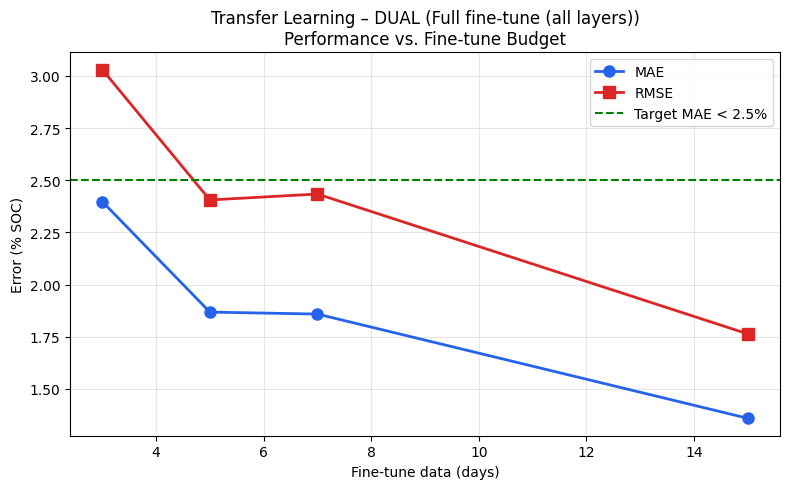


✅ Dual model becomes deployment‑ready (MAE < 2.5%) after 3 days.

✓ Dual model data efficiency experiment complete.


In [11]:
# ─── Cell 9 — Data Efficiency: Varying Fine‑tune Budget (DUAL model, LTO) ────
print('\n' + '='*70)
print('  LTO (Batt10) — Data Efficiency Experiment (dual model, varying ft days)')
print('='*70)

# Fine‑tune days to test 
ft_days_list = [3, 5, 7, 15]          # days of fine‑tune data
total_days_lto = 30                   # total available LTO days
best_strategy = 'unfreeze_all'        # change to 'freeze_feat', 'unfreeze_feat', 'progressive'

# Dual‑model settings
arch_name = 'DUAL'
builder_fn = build_dual_branch
ckpt_path = DUAL_CKPT                    
feat_layers = DUAL_FEAT_LAYERS
head_layers = DUAL_HEAD_LAYERS

budget_results = {}

for days in ft_days_list:
    print(f"\n--- Fine‑tuning with {days} days of LTO data ---")

    # Split LTO windows: first 'days' for fine‑tune, rest for test
    n_ft = int(len(ltoX_all) * days / total_days_lto)
    n_ft = max(1, min(n_ft, len(ltoX_all) - 1))   # ensure at least 1 test sample

    ftX = ltoX_all[:n_ft]
    ftY = ltoY_all[:n_ft]
    testX = ltoX_all[n_ft:]
    testY = ltoY_all[n_ft:]

    if len(testX) == 0 or len(ftX) < 2:
        print(f"  Skipping {days} days: test set empty or fine‑tune set too small.")
        continue

    # Split fine‑tune data into two halves (required by run_strategy_dual)
    n_half = len(ftX) // 2
    if n_half == 0:
        print(f"  Skipping {days} days: fine‑tune set too small.")
        continue

    ftX_s1 = ftX[:n_half];   ftY_s1 = ftY[:n_half]
    ftX_s2 = ftX[n_half:];   ftY_s2 = ftY[n_half:]

    # Run the chosen strategy on the dual model
    tf.random.set_seed(SEED); np.random.seed(SEED)
    met, _, _ = run_strategy_dual(
        best_strategy, ckpt_path,
        ftX_s1, ftY_s1, ftX_s2, ftY_s2,
        testX, testY
    )

    budget_results[days] = {'mae': met['MAE'], 'rmse': met['RMSE']}
    print(f"  Test MAE = {met['MAE']:.3f}%, RMSE = {met['RMSE']:.3f}%")

# ── Plotting ─────────────────────────────────────────────────────────────────
if budget_results:
    days = list(budget_results.keys())
    mae_vals = [budget_results[d]['mae'] for d in days]
    rmse_vals = [budget_results[d]['rmse'] for d in days]

    plt.figure(figsize=(8,5))
    plt.plot(days, mae_vals, 'o-', color='#2563EB', lw=2, markersize=8, label='MAE')
    plt.plot(days, rmse_vals, 's-', color='#DC2626', lw=2, markersize=8, label='RMSE')
    plt.axhline(y=2.5, color='green', linestyle='--', label='Target MAE < 2.5%')
    plt.xlabel('Fine‑tune data (days)')
    plt.ylabel('Error (% SOC)')
    plt.title(f'Transfer Learning – {arch_name} ({STRATEGIES[best_strategy]["label"]})\nPerformance vs. Fine‑tune Budget')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'dual_ft_budget_curve.png'), dpi=150)
    plt.show()

    # Minimum days to reach MAE < 2.5%
    below_threshold = [d for d in days if budget_results[d]['mae'] < 2.5]
    if below_threshold:
        min_days = min(below_threshold)
        print(f"\n✅ Dual model becomes deployment‑ready (MAE < 2.5%) after {min_days} days.")
    else:
        print("\n⚠️ Dual model did not reach MAE < 2.5% within tested budgets.")
else:
    print("No valid results to plot.")

print('\n✓ Dual model data efficiency experiment complete.')

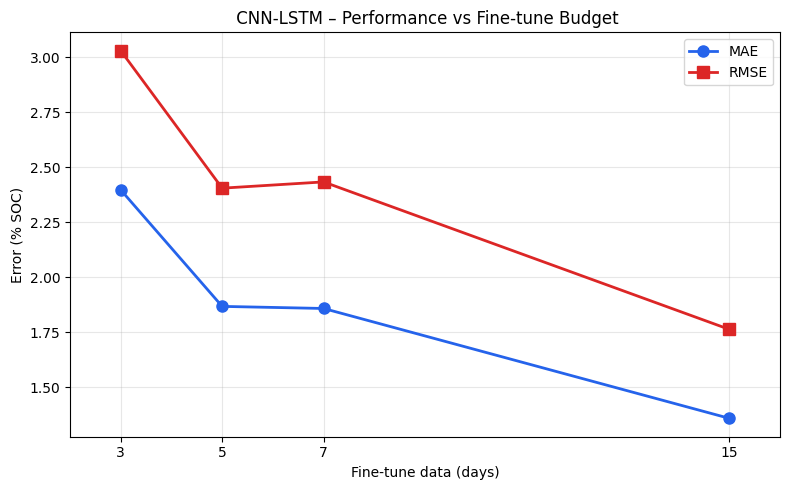


✅ Dual model becomes deployment‑ready (MAE < 2.5%) after 3 days.

✓ Dual model data efficiency experiment complete.


In [14]:
# ── Plotting ─────────────────────────────────────────────────────────────────
if budget_results:
    days = list(budget_results.keys())
    mae_vals = [budget_results[d]['mae'] for d in days]
    rmse_vals = [budget_results[d]['rmse'] for d in days]

    plt.figure(figsize=(8,5))
    plt.plot(days, mae_vals, 'o-', color='#2563EB', lw=2, markersize=8, label='MAE')
    plt.plot(days, rmse_vals, 's-', color='#DC2626', lw=2, markersize=8, label='RMSE')

    plt.xticks(days)
    plt.xlim(min(days) - 1, max(days) + 1)

    plt.xlabel('Fine‑tune data (days)')
    plt.ylabel('Error (% SOC)')
    plt.title(' CNN-LSTM – Performance vs Fine‑tune Budget')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'dual_ft_budget_curve.png'), dpi=150)
    plt.show()

    # Minimum days to reach MAE < 2.5% (threshold kept for printout only)
    below_threshold = [d for d in days if budget_results[d]['mae'] < 2.5]
    if below_threshold:
        min_days = min(below_threshold)
        print(f"\n✅ Dual model becomes deployment‑ready (MAE < 2.5%) after {min_days} days.")
    else:
        print("\n⚠️ Dual model did not reach MAE < 2.5% within tested budgets.")
else:
    print("No valid results to plot.")

print('\n✓ Dual model data efficiency experiment complete.')

In [15]:
# ─── Cell 11 — Data Efficiency Results Table ────────────────────────────────
print('\n' + '='*70)
print('  LTO (Batt10) — Fine‑tune Budget vs. Performance')
print('='*70)
print(f'  {"Days":>6} {"MAE (%)":>10} {"RMSE (%)":>10} {"Accuracy (%)":>12}')
print('-'*50)

best_mae = 999
best_days = None
for days, res in budget_results.items():
    mae = res['mae']
    rmse = res['rmse']
    acc = max(0, (1 - mae/100)*100)
    print(f'  {days:6d} {mae:10.4f} {rmse:10.4f} {acc:12.2f}')
    if mae < best_mae:
        best_mae = mae
        best_days = days

print('-'*50)
print(f'\n  BEST MAE = {best_mae:.4f}% at {best_days} days of fine‑tuning.')
print('='*70)

# Save metrics to JSON
budget_save = {str(days): {'MAE': res['mae'], 'RMSE': res['rmse']}
               for days, res in budget_results.items()}
with open(os.path.join(SAVE_DIR, 'budget_metrics.json'), 'w') as f:
    json.dump(budget_save, f, indent=2)
print('\n✓ Budget metrics saved.')


  LTO (Batt10) — Fine‑tune Budget vs. Performance
    Days    MAE (%)   RMSE (%) Accuracy (%)
--------------------------------------------------
       3     2.3979     3.0308        97.60
       5     1.8684     2.4059        98.13
       7     1.8589     2.4343        98.14
      15     1.3594     1.7639        98.64
--------------------------------------------------

  BEST MAE = 1.3594% at 15 days of fine‑tuning.

✓ Budget metrics saved.
